# Multi-Temporal Assessment of Surface Water Dynamics in Indian Lakes Using Sentinel-2 Imagery and NDWI

Author: Pranav  
Internship Project – Geospatial AI  
Year: 2026

## 1. Introduction

Monitoring surface water dynamics is crucial for understanding environmental changes, urban encroachment, and hydrological variations. Satellite remote sensing provides a scalable and cost-effective method for long-term monitoring of water bodies.

This project aims to quantify lake area changes between 2018 and 2024 using Sentinel-2 satellite imagery and NDWI-based water extraction.

## 2. Data Collection

### Data Source
- Sentinel-2 Surface Reflectance Dataset
- Accessed via Google Earth Engine
- Spatial resolution: 10 meters

### Bands Used
- B3 (Green)
- B8 (Near Infrared - NIR)

### Preprocessing Criteria
- Cloud coverage less than 10%
- Median composite generated for each year

In [1]:
import ee

ee.Authenticate()      # Run only once
ee.Initialize(project="lake-encroachment-analysis")

# ==================== LIST OF LAKES ====================
lakes = {
    "Bellandur":        [77.635, 12.915, 77.685, 12.950],   
    "Sambhar":          [74.95,  26.85,  75.30,  27.10],    
    "Pulicat":          [80.15,  13.40,  80.35,  13.70],    
    "Dal":              [74.80,  34.05,  74.90,  34.15],    
    "Chilika":          [85.00,  19.60,  85.40,  19.85],    
    "Vembanad":         [76.35,  9.40,   76.55,  9.70],     
    "Loktak":           [93.75,  24.40,  93.95,  24.60]   
}

years = [2018, 2024]

print("Starting export for multiple lakes...\n")

for lake_name, bbox in lakes.items():
    region = ee.Geometry.Rectangle(bbox)
    
    for year in years:
        collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
            .filterBounds(region) \
            .filterDate(f'{year}-01-01', f'{year}-12-31') \
            .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10)) \
            .select(['B8', 'B4', 'B3', 'B2'])

        image = collection.median()

        task = ee.batch.Export.image.toDrive(
            image=image,
            description=f'{lake_name.lower()}_lake_{year}',
            folder='multi_lake_data',
            scale=10,
            region=region,
            maxPixels=1e8
        )
        task.start()
        
        print(f"Exporting {lake_name} Lake - {year} ...")

print("\nAll tasks submitted successfully!")
print("Go to your Google Drive → 'multi_lake_data' folder and download the .tif files.")

Starting export for multiple lakes...

Exporting Bellandur Lake - 2018 ...
Exporting Bellandur Lake - 2024 ...
Exporting Sambhar Lake - 2018 ...
Exporting Sambhar Lake - 2024 ...
Exporting Pulicat Lake - 2018 ...
Exporting Pulicat Lake - 2024 ...
Exporting Dal Lake - 2018 ...
Exporting Dal Lake - 2024 ...
Exporting Chilika Lake - 2018 ...
Exporting Chilika Lake - 2024 ...
Exporting Vembanad Lake - 2018 ...
Exporting Vembanad Lake - 2024 ...
Exporting Loktak Lake - 2018 ...
Exporting Loktak Lake - 2024 ...

All tasks submitted successfully!
Go to your Google Drive → 'multi_lake_data' folder and download the .tif files.


## 3. Data Preparation

After exporting Sentinel-2 imagery from Google Earth Engine, the images were downloaded in GeoTIFF format. These images contain multiple spectral bands at 10-meter spatial resolution.

The preprocessing steps performed include:

- Reading GeoTIFF files using the `rasterio` library.
- Extracting relevant spectral bands (Green and NIR).
- Handling division-by-zero cases during index computation.
- Normalizing reflectance values for visualization purposes.

Each pixel represents an area of 10m × 10m (100 square meters), which allows direct conversion of pixel counts into surface area measurements.

In [2]:
import rasterio
import numpy as np

def calculate_water_area(tif_path):
    with rasterio.open(tif_path) as src:
        nir = src.read(1).astype(np.float64)     # NIR band
        green = src.read(3).astype(np.float64)   # Green band
        
        denominator = green + nir
        denominator[denominator == 0] = np.nan
        
        ndwi = (green - nir) / denominator
        
        water_mask = ndwi > 0
        
        water_pixels = np.sum(water_mask)
        area_sqm = water_pixels * 100
        
        return water_mask, area_sqm


## 4. Exploratory Data Analysis (EDA)

Before performing water extraction, the satellite images were visually examined to observe differences between 2018 and 2024.

RGB composites were generated using Sentinel-2 bands to visually inspect shoreline changes, vegetation patterns, and potential encroachment regions.

Water bodies typically appear darker in Near-Infrared (NIR) bands due to strong absorption, which forms the basis for spectral index-based classification.

## 5. Methodology – NDWI Based Water Extraction

The Normalized Difference Water Index (NDWI) is used to identify water bodies from satellite imagery.

The formula is:

NDWI = (Green - NIR) / (Green + NIR)

Water strongly absorbs Near-Infrared radiation while reflecting green light. As a result, water pixels produce higher NDWI values compared to vegetation or built-up areas.

A threshold of NDWI > 0 was applied to classify pixels as water.

This rule-based classification approach provides a computationally efficient method for large-scale water body extraction.

## 6. Area Calculation

Sentinel-2 imagery has a spatial resolution of 10 meters. Therefore:

Pixel Area = 10m × 10m = 100 square meters

The total water area was calculated by counting the number of pixels classified as water and multiplying by 100.

Area Change = Water Area (2024) − Water Area (2018)

The change was further converted into hectares and square kilometers for better interpretability.

## 7. Results and Visualization

The extracted water masks were compared between 2018 and 2024 for each selected lake.

The results were visualized using:

- Binary water masks
- Bar graph comparisons
- Tabular summaries


Processing images and generating visualization...

Graph saved successfully as 'lake_water_masks_comparison.jpg'


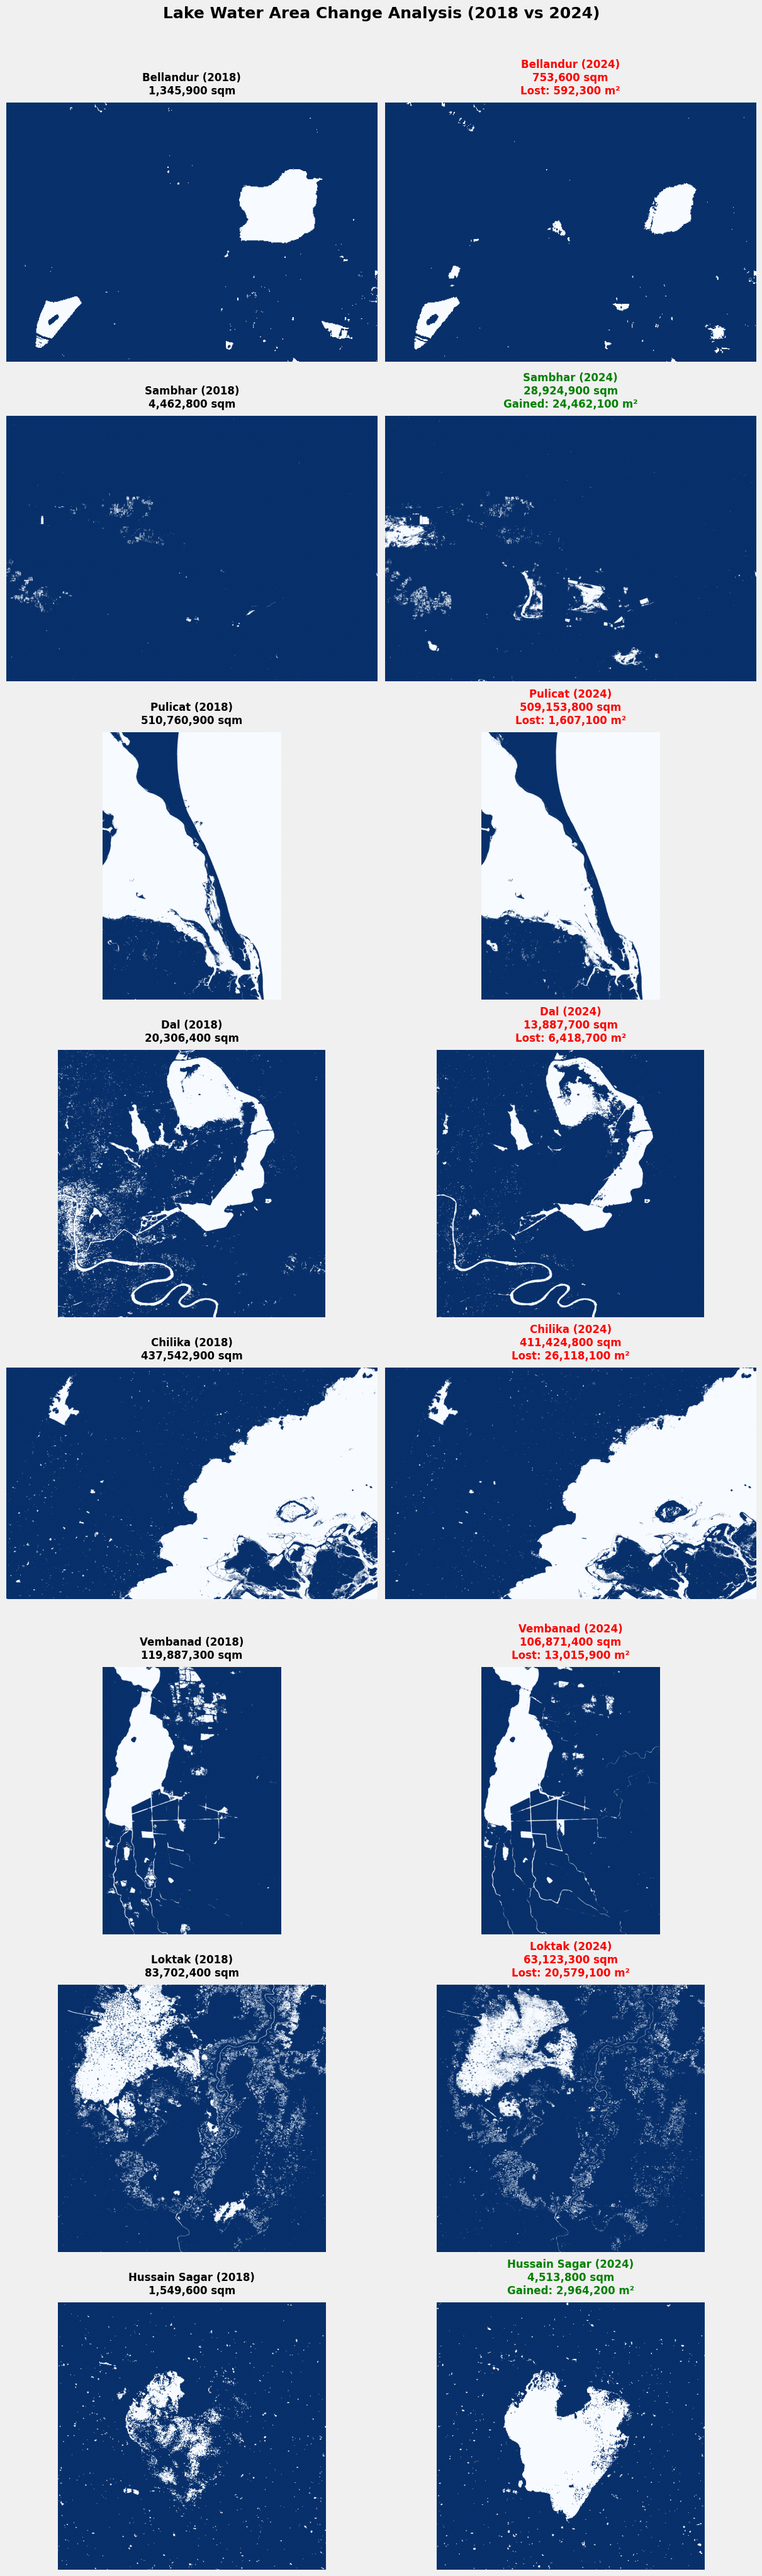

In [3]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

def calculate_water_area(tif_path):
    with rasterio.open(tif_path) as src:
        nir = src.read(1).astype(np.float64)     # NIR
        green = src.read(3).astype(np.float64)   # Green
        
        denominator = green + nir
        denominator[denominator == 0] = np.nan
        
        ndwi = (green - nir) / denominator
        
        water_mask = ndwi > 0
        
        water_pixels = np.sum(water_mask)
        area_sqm = water_pixels * 100
        
        return water_mask, area_sqm

# ============================================================
# DATASET CONFIGURATION
# ============================================================
lakes = [
    ("Bellandur", r"D:\\Lake encroachment\\tif_files\\2018\\bellandur_lake_2018.tif", r"D:\\Lake encroachment\\tif_files\\2024\\bellandur_lake_2024.tif"),
    ("Sambhar", r"D:\\Lake encroachment\\tif_files\\2018\\sambhar_lake_2018.tif", r"D:\\Lake encroachment\\tif_files\\2024\\sambhar_lake_2024.tif"),
    ("Pulicat", r"D:\\Lake encroachment\\tif_files\\2018\\pulicat_lake_2018.tif", r"D:\\Lake encroachment\\tif_files\\2024\\pulicat_lake_2024.tif"),
    ("Dal", r"D:\\Lake encroachment\\tif_files\\2018\\dal_lake_2018.tif", r"D:\\Lake encroachment\\tif_files\\2024\\dal_lake_2024.tif"),
    ("Chilika", r"D:\\Lake encroachment\\tif_files\\2018\\chilika_lake_2018.tif", r"D:\\Lake encroachment\\tif_files\\2024\\chilika_lake_2024.tif"),
    ("Vembanad", r"D:\\Lake encroachment\\tif_files\\2018\\vembanad_lake_2018.tif", r"D:\\Lake encroachment\\tif_files\\2024\\vembanad_lake_2024.tif"),
    ("Loktak", r"D:\\Lake encroachment\\tif_files\\2018\\loktak_lake_2018.tif", r"D:\\Lake encroachment\\tif_files\\2024\\loktak_lake_2024.tif"),
    ("Hussain Sagar", r"D:\\Lake encroachment\\tif_files\\2018\\hussain_sagar_2018.tif", r"D:\\Lake encroachment\\tif_files\\2024\\hussain_sagar_2024.tif")
]

print("\nProcessing images and generating visualization...\n")

# ============================================================
# PLOTTING LOGIC
# ============================================================
rows = len(lakes)
fig, axes = plt.subplots(rows, 2, figsize=(12, 5 * rows), constrained_layout=True)
fig.patch.set_facecolor('#f0f0f0') 

for i, (lake_name, file_2018, file_2024) in enumerate(lakes):
    
    mask_2018, area_2018 = calculate_water_area(file_2018)
    mask_2024, area_2024 = calculate_water_area(file_2024)
    
    area_difference = area_2024 - area_2018
    change_status = "Gained" if area_difference > 0 else "Lost"
    text_color = 'green' if area_difference > 0 else 'red'

    title_2018 = f"{lake_name} (2018)\n{area_2018:,.0f} sqm"
    axes[i, 0].imshow(mask_2018, cmap='Blues_r')
    axes[i, 0].set_title(title_2018, fontsize=12, fontweight='bold', pad=10)
    axes[i, 0].axis("off")
    
    title_2024 = (f"{lake_name} (2024)\n"
                  f"{area_2024:,.0f} sqm\n"
                  f"{change_status}: {abs(area_difference):,.0f} m²")
    
    axes[i, 1].imshow(mask_2024, cmap='Blues_r')
    axes[i, 1].set_title(title_2024, fontsize=12, fontweight='bold', color=text_color, pad=10)
    axes[i, 1].axis("off")

plt.suptitle("Lake Water Area Change Analysis (2018 vs 2024)", fontsize=18, fontweight='bold', y=1.02)

# ==================== SAVE AS JPG ====================
plt.savefig('lake_water_masks_comparison.jpg', format='jpg', dpi=300, bbox_inches='tight')
print("Graph saved successfully as 'lake_water_masks_comparison.jpg'")

plt.show()

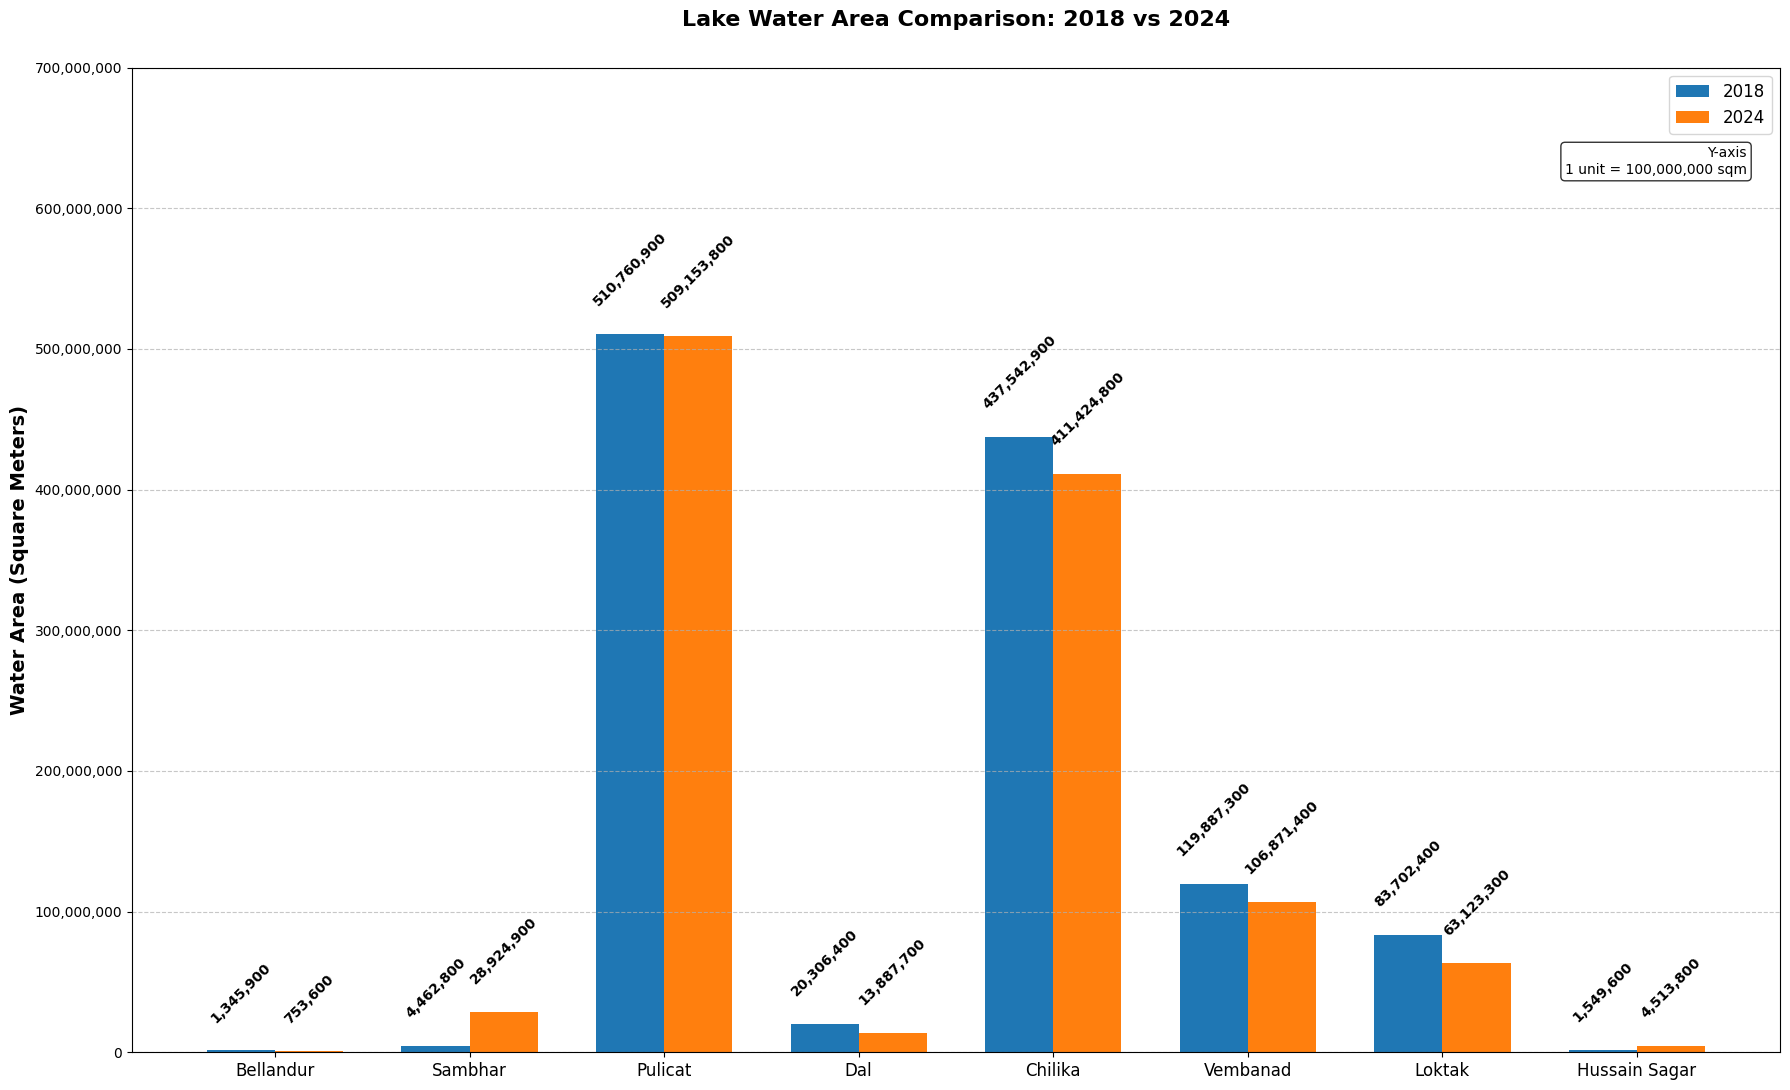

Final graph saved successfully!


In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

# ==================== DATA ====================
lakes = ['Bellandur', 'Sambhar', 'Pulicat', 'Dal', 'Chilika', 
         'Vembanad', 'Loktak', 'Hussain Sagar']

area_2018 = [1345900, 4462800, 510760900, 20306400, 437542900, 
             119887300, 83702400, 1549600]

area_2024 = [753600, 28924900, 509153800, 13887700, 411424800, 
             106871400, 63123300, 4513800]

x = np.arange(len(lakes))
width = 0.35

fig, ax = plt.subplots(figsize=(18, 11))

bars1 = ax.bar(x - width/2, area_2018, width, label='2018', color='#1f77b4')
bars2 = ax.bar(x + width/2, area_2024, width, label='2024', color='#ff7f0e')

# Y-axis increased to 700 million as requested
ax.set_ylim(0, 700_000_000)

def full_number(x, pos):
    return f'{int(x):,}'

ax.yaxis.set_major_formatter(FuncFormatter(full_number))
ax.set_ylabel('Water Area (Square Meters)', fontsize=14, fontweight='bold')
ax.set_title('Lake Water Area Comparison: 2018 vs 2024', fontsize=16, fontweight='bold', pad=30)

ax.set_xticks(x)
ax.set_xticklabels(lakes, fontsize=12, rotation=0, ha='center')

ax.legend(fontsize=12, loc='upper right')

# Diagonal labels above bars
def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        if height == 0:
            continue
        ax.annotate(f'{height:,.0f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 18),
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=10, fontweight='bold',
                    rotation=45)

autolabel(bars1)
autolabel(bars2)

# Scale note at top-right
ax.text(0.98, 0.92, "Y-axis\n1 unit = 100,000,000 sqm", 
        transform=ax.transAxes, fontsize=10, 
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig('results/lake_area_comparison_graph_final.png', dpi=300, bbox_inches='tight')
plt.show()

print("Final graph saved successfully!")

In [5]:
import pandas as pd

# Data from your results
data = {
    'Lake Name': [
        'Bellandur', 'Sambhar', 'Pulicat', 'Dal', 'Chilika',
        'Vembanad', 'Loktak', 'Hussain Sagar'
    ],
    '2018 Water Area (sq m)': [
        1345900, 4462800, 510760900, 20306400, 437542900,
        119887300, 83702400, 1549600
    ],
    '2024 Water Area (sq m)': [
        753600, 28924900, 509153800, 13887700, 411424800,
        106871400, 63123300, 4513800
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

# Calculate difference
df['Change (sq m)'] = df['2024 Water Area (sq m)'] - df['2018 Water Area (sq m)']

# Add status and color coding for display
df['Status'] = df['Change (sq m)'].apply(lambda x: 'Lost' if x < 0 else 'Gained')
df['Change (hectares)'] = (df['Change (sq m)'] / 10000).round(2)
df['Change (sq km)'] = (df['Change (sq m)'] / 1000000).round(4)

# Reorder columns to match your screenshot
df = df[['Lake Name', '2018 Water Area (sq m)', '2024 Water Area (sq m)', 
         'Change (sq m)', 'Status', 'Change (hectares)', 'Change (sq km)']]

# Print nicely formatted table
print("\n" + "="*80)
print("          LAKE WATER AREA CHANGE ANALYSIS (2018 vs 2024)")
print("="*80)
print(df.to_string(index=False))
print("="*80)

# Save to CSV (optional, for report)
df.to_csv('results/lake_area_summary_table.csv', index=False)
print("\nTable saved as 'results/lake_area_summary_table.csv'")


          LAKE WATER AREA CHANGE ANALYSIS (2018 vs 2024)
    Lake Name  2018 Water Area (sq m)  2024 Water Area (sq m)  Change (sq m) Status  Change (hectares)  Change (sq km)
    Bellandur                 1345900                  753600        -592300   Lost             -59.23         -0.5923
      Sambhar                 4462800                28924900       24462100 Gained            2446.21         24.4621
      Pulicat               510760900               509153800       -1607100   Lost            -160.71         -1.6071
          Dal                20306400                13887700       -6418700   Lost            -641.87         -6.4187
      Chilika               437542900               411424800      -26118100   Lost           -2611.81        -26.1181
     Vembanad               119887300               106871400      -13015900   Lost           -1301.59        -13.0159
       Loktak                83702400                63123300      -20579100   Lost           -2057.91       

### Observations

- Some lakes show significant reduction in surface water area.
- Certain lakes exhibit expansion, possibly due to seasonal or hydrological variations.
- Multi-temporal satellite analysis effectively highlights spatial changes in water bodies.

## 8. Conclusion

This study demonstrates the effectiveness of NDWI-based spectral index analysis for monitoring lake surface dynamics using Sentinel-2 imagery.

The multi-temporal comparison between 2018 and 2024 highlights noticeable variations in water extent across selected Indian lakes.

While the approach is computationally efficient, it relies on a fixed threshold and does not incorporate seasonal segmentation or machine learning-based refinement.

Future work could include:
- Seasonal time-series analysis
- Machine learning-based water segmentation
- Integration with ground truth validation

This project focused on analyzing lake encroachment using satellite imagery and geospatial techniques. By leveraging remote sensing data and applying the Normalized Difference Water Index (NDWI), water bodies were extracted and quantified from multi-temporal satellite images. The computed water area statistics and visual comparisons enabled the identification of spatial variations and potential encroachment patterns.

The workflow included data acquisition, preprocessing, index computation, water pixel classification, area estimation, and visualization of results. The generated outputs demonstrate how satellite-based monitoring can be effectively used for assessing environmental changes in water bodies.

This study highlights the practical applicability of Earth observation data in environmental monitoring and urban planning. Even with a limited dataset, the methodology establishes a replicable pipeline for detecting and quantifying changes in lake extents.

# Key Observations
NDWI effectively distinguishes water pixels from surrounding land features.
Multi-temporal analysis allows detection of changes in water spread.
Visualization graphs clearly represent area differences across datasets.
The workflow can be extended for large-scale monitoring applications.

# Future Scope
1) Incorporating multi-year temporal datasets for long-term change detection.
2) Applying machine learning models for automated water body classification.
3) Integrating GIS-based boundary shapefiles for more precise area computation.
4) Developing an automated alert system for detecting rapid encroachment.
5) Expanding the approach to multiple lakes for regional-scale ecological assessment.